## 1. Dataset


Source: ```https://www.kaggle.com/datasets/apoorvwatsky/supply-chain-shipment-pricing-data```,

```https://www.usaid.gov/data/dataset/0162a542-4f2e-4fe2-ad5d-8f6ed2344056```

This data set provides supply chain health commodity shipment and pricing data. 

Specifically, the data set identifies Antiretroviral (ARV) and HIV lab shipments to supported countries. In addition, 

the data set provides the commodity pricing and associated supply chain expenses necessary to move the commodities to countries for use.

### 1.1 Objective

1. Price Estimate
2. Cost Analysis
3. Delay Prediction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from importlib import reload


import seaborn as sns
from sklearn import tree
from sklearn.feature_selection import mutual_info_classif
from collections import defaultdict

from tqdm import tqdm
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, classification_report

import inspect


sys.path.append('/Users/cheungjustin/PycharmProjects/CIBer')
import util as put
import stats as pstats
import analytics as pan
import plot as pplot

### 1.2. Data Cleaning

In [2]:
df = pd.read_csv('../Raw/SCMS_Delivery_History_Dataset_20150929.csv', encoding='ISO-8859-1')
df = df.set_index('ID')
df.sample(5).T#.iloc[:, 17:24].sample(5).values

ID,83981,8465,85892,11291,84247
Project Code,104-CI-T30,116-ZA-T01,102-CD-T30,114-UG-T01,102-BI-T30
PQ #,FPQ-4378,Pre-PQ Process,FPQ-9906,Pre-PQ Process,FPQ-11661
PO / SO #,SO-34410,SCMS-23500,SO-42340,SO-17830,SO-44670
ASN/DN #,DN-1662,ASN-2293,DN-2812,DN-990,DN-3118
Country,Côte d'Ivoire,South Africa,"Congo, DRC",Uganda,Burundi
Managed By,PMO - US,PMO - US,PMO - US,PMO - US,PMO - US
Fulfill Via,From RDC,Direct Drop,From RDC,From RDC,From RDC
Vendor INCO Term,N/A - From RDC,DDP,N/A - From RDC,N/A - From RDC,N/A - From RDC
Shipment Mode,Air,Truck,Air,Air,Air
PQ First Sent to Client Date,10/15/2009,Pre-PQ Process,5/15/2012,Pre-PQ Process,2/20/2013


In [3]:
import re

def get_inside(s, l, r):
    if s is None or len(s) == 0:
        return None
    m = re.findall(rf'{l}(.*?){r}', s)
    assert len(m) == 1, s
    return int(m[0])
    
def split_str_cols(s, pat, s_name=None):
    if s_name is None:
        s_name = s.name
    return s.str.split(pat, expand=True).add_prefix(s_name + '_').replace('', np.nan)


df_new = df.copy()

# 0. Manual Replacement
df_new['PQ #'] = df_new['PQ #'].replace({'Pre-PQ Process': 'PrePQ-'})

# 1. Split String Columns
for col in ['Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #']:
    df_new = pd.concat([df_new.drop(columns=col), split_str_cols(df_new[col], '-')], axis=1)

# 2. Convert to datetime
date_cols = ['Scheduled Delivery Date', 'Delivered to Client Date', 'Delivery Recorded Date']

for col in date_cols:
    df_new[col] = pd.to_datetime(df_new[col], format='%d-%b-%y')


date_cols2 = ['PQ First Sent to Client Date', 'PO Sent to Vendor Date']
for col in date_cols2:
    s = df_new[col]
    s_new = pd.to_datetime(s, format='%m/%d/%Y', errors='coerce')
    df_new[col] = s_new
    
    if (s.notna() & s_new.isna()).sum() > 0:
        df_new[col+'_str'] = s[s_new.isna()]


# 3. Convert Num dtypes
num_cols = ['PQ #_1', 'PO / SO #_1', 'ASN/DN #_1', 
            'Weight (Kilograms)', 'Freight Cost (USD)']

for col in num_cols:
    s = df_new[col]
    s_new = pd.to_numeric(s, errors='coerce')
    df_new[col] = s_new

    if (s.notna() & s_new.isna()).sum() > 0:
        df_new[col+'_str'] = s[s_new.isna()]


# 4. Manual Impute (Costs need to be inferred from First Line Destination)
for corr_col in ['Weight (Kilograms)', 'Freight Cost (USD)']:
    corr_col_id = df_new[corr_col + '_str'].replace({np.nan: None, 
                                                     'Weight Captured Separately': None,
                                                    'Freight Included in Commodity Cost': None,
                                                    'Invoiced Separately': None})
    
    corr_col_id = corr_col_id.apply(lambda s: get_inside(s, l='ID#:', r=r'\)'))
    corr_val = corr_col_id.apply(lambda s: df_new.loc[s, corr_col] if not np.isnan(s) else np.nan)
    df_new[corr_col] = df_new[corr_col].fillna(corr_val)
    df_new[corr_col + '_str'] = df_new[corr_col + '_str'][corr_col_id.isna()]

# 5. Change String columns to lowercase
df_str = df_new.select_dtypes('object')
df_new.loc[:, df_str.columns] = df_str.apply(lambda s: s.str.lower())

# 6. Drop Columns with no information
df_new = df_new.loc[:, df_new.nunique() > 1]
df_new.sample(5).T

ID,64377,11076,15399,12212,84186
Country,vietnam,mozambique,nigeria,zimbabwe,nigeria
Managed By,pmo - us,pmo - us,pmo - us,pmo - us,pmo - us
Fulfill Via,direct drop,from rdc,direct drop,from rdc,from rdc
Vendor INCO Term,exw,n/a - from rdc,exw,n/a - from rdc,n/a - from rdc
Shipment Mode,air,air,air,truck,air
PQ First Sent to Client Date,2014-10-24 00:00:00,NaT,2013-10-17 00:00:00,NaT,2012-03-01 00:00:00
PO Sent to Vendor Date,2014-10-30 00:00:00,NaT,2013-11-04 00:00:00,NaT,NaT
Scheduled Delivery Date,2015-03-31 00:00:00,2009-12-11 00:00:00,2013-12-17 00:00:00,2008-11-19 00:00:00,2012-08-31 00:00:00
Delivered to Client Date,2015-03-31 00:00:00,2009-12-11 00:00:00,2013-12-17 00:00:00,2008-11-19 00:00:00,2012-08-14 00:00:00
Delivery Recorded Date,2015-03-31 00:00:00,2009-12-11 00:00:00,2013-12-20 00:00:00,2008-11-19 00:00:00,2012-08-14 00:00:00


In [4]:
# First Split the product into molecule and tests
tests_groups = df_new.loc[df_new['Dosage'].isna(), 'Product Group'].unique()
is_tests = df_new['Product Group'].isin(tests_groups)

# Get the Mole Name
mole = df_new.loc[~is_tests, 'Molecule/Test Type'].str.split(' ').str[0]
mole = mole.str.rstrip(',').str.split(re.compile(r'[/|\+]'), expand=True)

# Get the Dosage
dosage = df_new.loc[~is_tests, 'Dosage'].apply(lambda s: re.sub(r'[A-Za-z]', '', s))# if isinstance(s, str) else np.nan)
dosage = dosage.str.rstrip('/')
dosage = dosage.str.split(re.compile(r'[/|\+]'), expand=True)
dosage = dosage.astype(float)

# Concat to get the dosage per each molecule
mole_dosage = pd.concat({'Molecule': mole.stack(), 'Dosage': dosage.stack()}, join='inner', axis=1)
mole_dosage = mole_dosage.set_index('Molecule', append=True).droplevel(1)
mole_dosage = mole_dosage.unstack('Molecule')['Dosage']#.rename_axis(None, axis=1)
mole_dosage = mole_dosage.fillna(0)
mole_dosage

Molecule,abacavir,amodiaquine,artemether,artesunate,atazanavir,chloroquine,darunavir,didanosine,efavirenz,emtricitabine,...,primaquine,pyrimethamine,quinine,raltegravir,ritonavir,saquinavir,stavudine,sulfadoxine,tenofovir,zidovudine
ID,,,,,,,,,,,,,,,,,,,,,
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,0.0,0.0
23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0
44,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,200.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86818,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,60.0
86819,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,300.0
86821,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,600.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,300.0,0.0


In [5]:
# Item Description is already contained in other columns
df_new2 = df_new.drop(columns=['Molecule/Test Type', 'Dosage', 'Item Description']) 
df_new2 = df_new2.join(mole_dosage, how='left')
df_new2

,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,PQ First Sent to Client Date,PO Sent to Vendor Date,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,...,primaquine,pyrimethamine,quinine,raltegravir,ritonavir,saquinavir,stavudine,sulfadoxine,tenofovir,zidovudine
ID,,,,,,,,,,,,,,,,,,,,,
1,côte d'ivoire,pmo - us,direct drop,exw,air,NaT,NaT,2006-06-02,2006-06-02,2006-06-02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,vietnam,pmo - us,direct drop,exw,air,NaT,NaT,2006-11-14,2006-11-14,2006-11-14,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,côte d'ivoire,pmo - us,direct drop,fca,air,NaT,NaT,2006-08-27,2006-08-27,2006-08-27,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,vietnam,pmo - us,direct drop,exw,air,NaT,NaT,2006-09-01,2006-09-01,2006-09-01,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16,vietnam,pmo - us,direct drop,exw,air,NaT,NaT,2006-08-11,2006-08-11,2006-08-11,...,0.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86818,zimbabwe,pmo - us,from rdc,n/a - from rdc,truck,2014-10-16,NaT,2015-07-31,2015-07-15,2015-07-20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,60.0
86819,côte d'ivoire,pmo - us,from rdc,n/a - from rdc,truck,2014-10-24,NaT,2015-07-31,2015-08-06,2015-08-07,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,300.0
86821,zambia,pmo - us,from rdc,n/a - from rdc,truck,2014-08-12,NaT,2015-08-31,2015-08-25,2015-09-03,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,300.0,0.0


## 2. EDA Wrapper

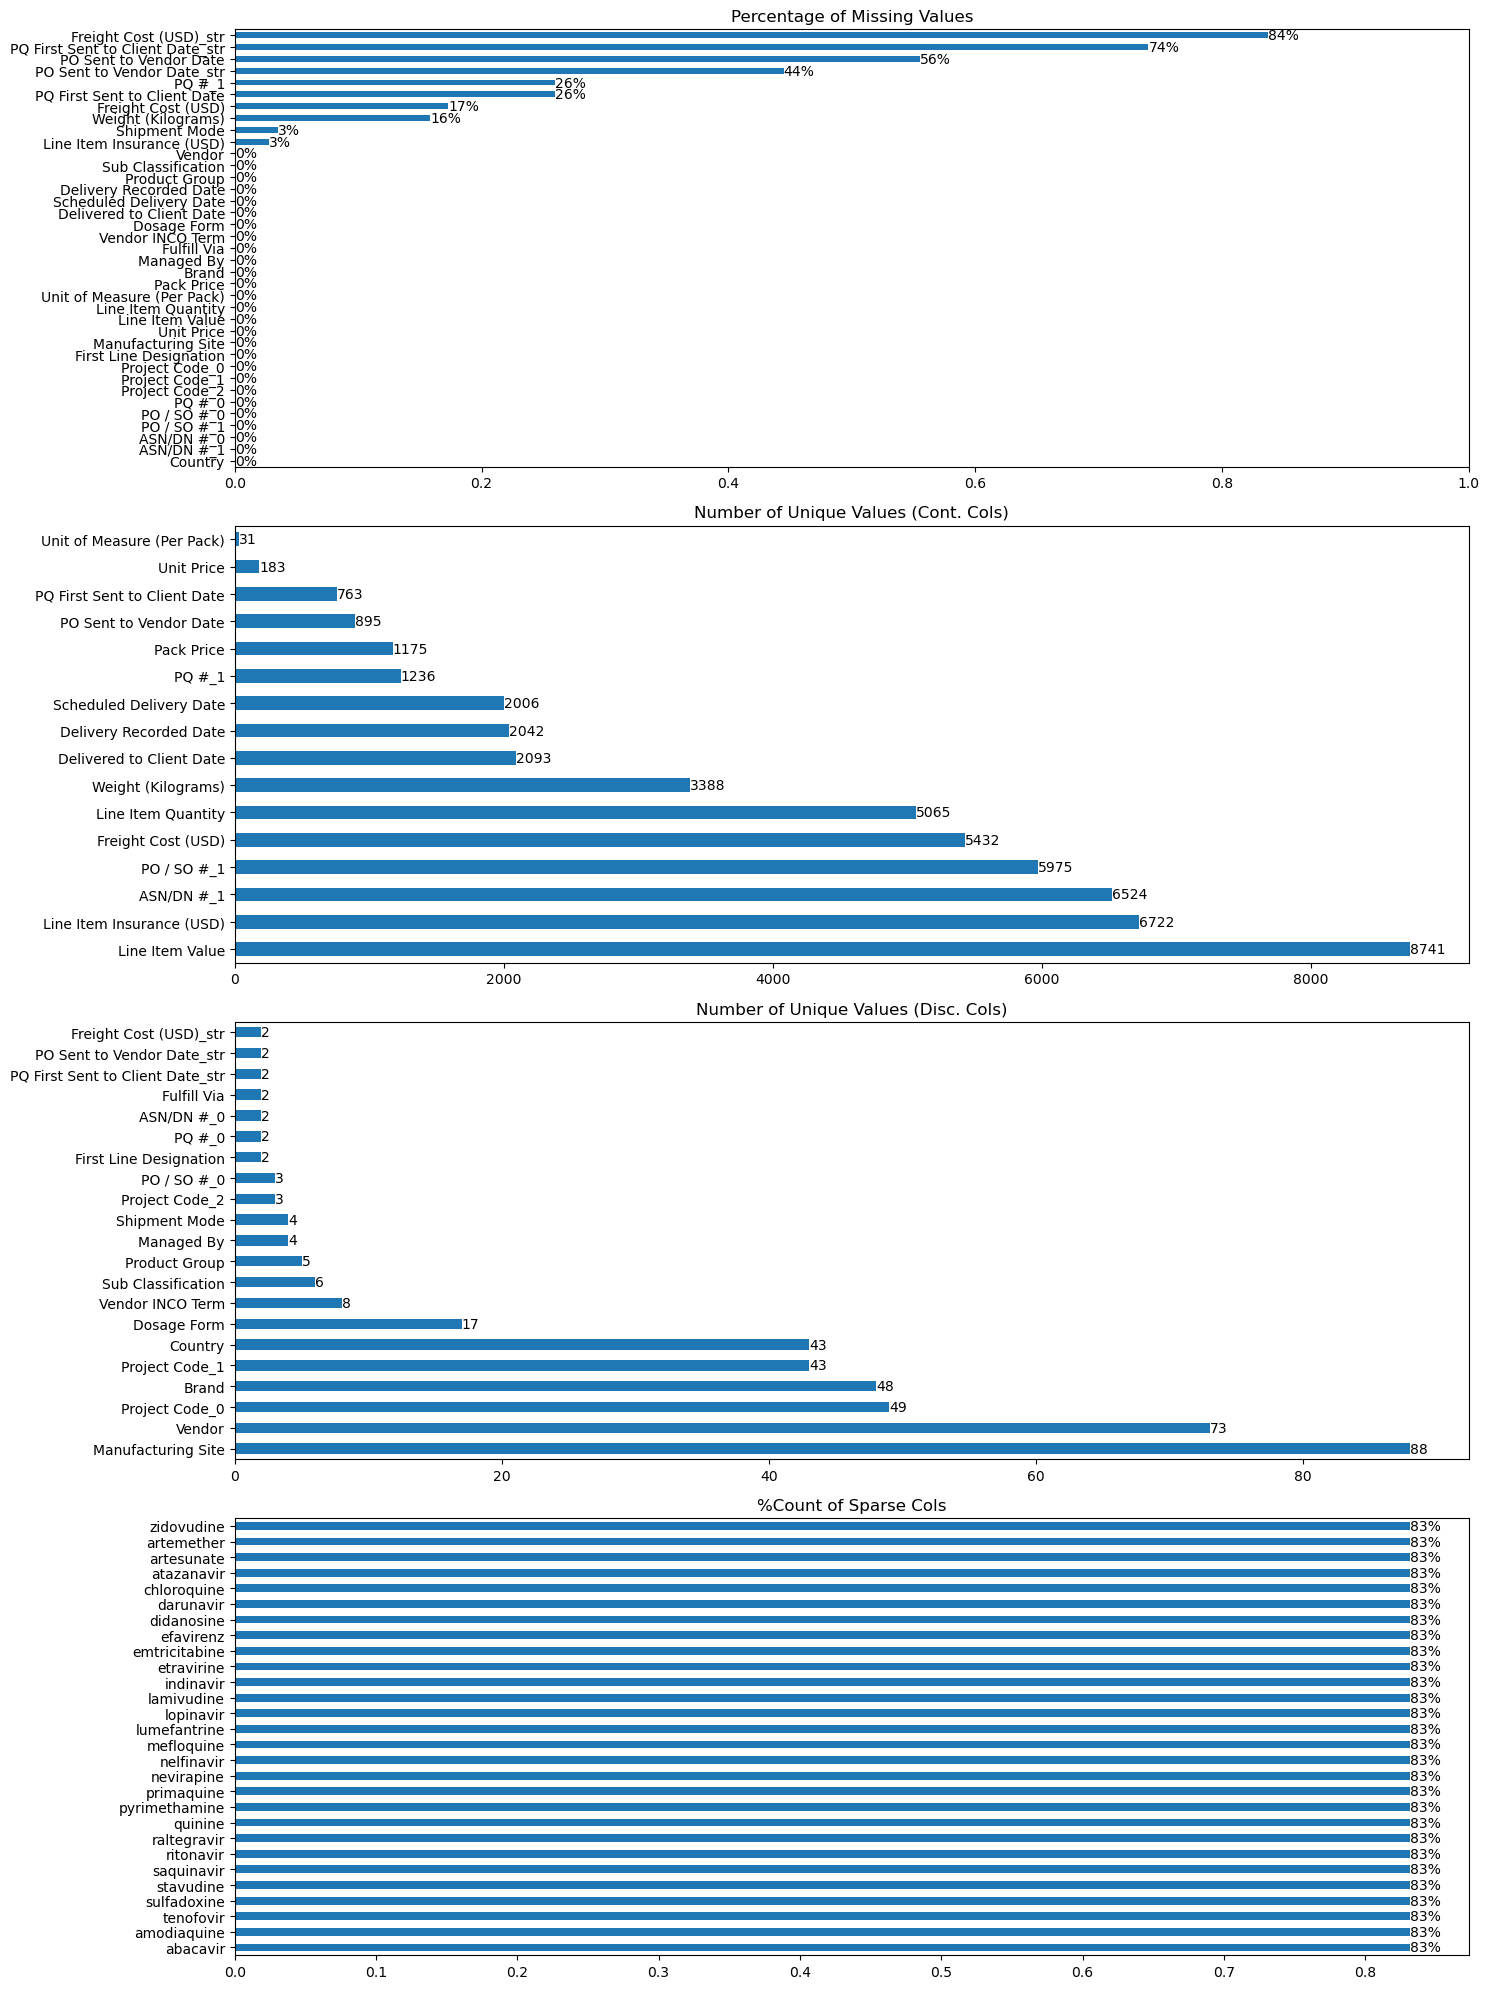

In [6]:
target = 'Unit Price'
cont_thres = 'log2'
random_state = 4012
verbose = False

dta = pan.DataAnalyzer(df_new2, target=target, verbose=verbose,
                      sparse_cols=list(mole_dosage.columns),
                      cont_thres=cont_thres, random_state=random_state)

dta.data_quality_check(one_figsize=(15, 5));

In [7]:
# dta.plot_categ_stats();

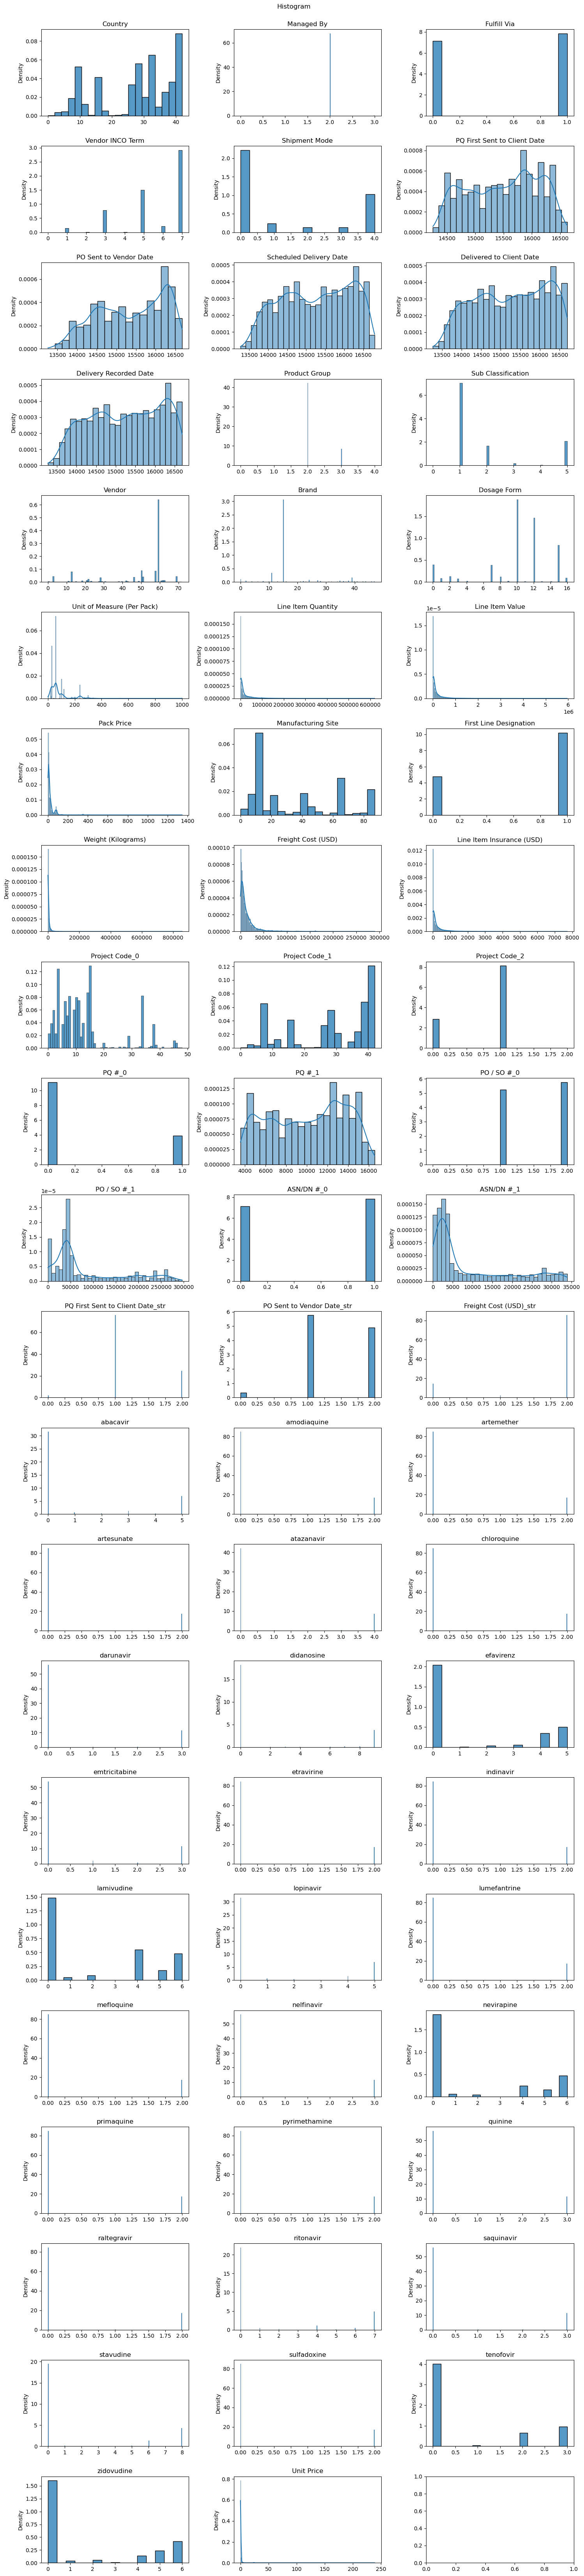

In [8]:
dta.dist_plot();

100%|████████████████████████████████████████| 703/703 [00:03<00:00, 178.11it/s]


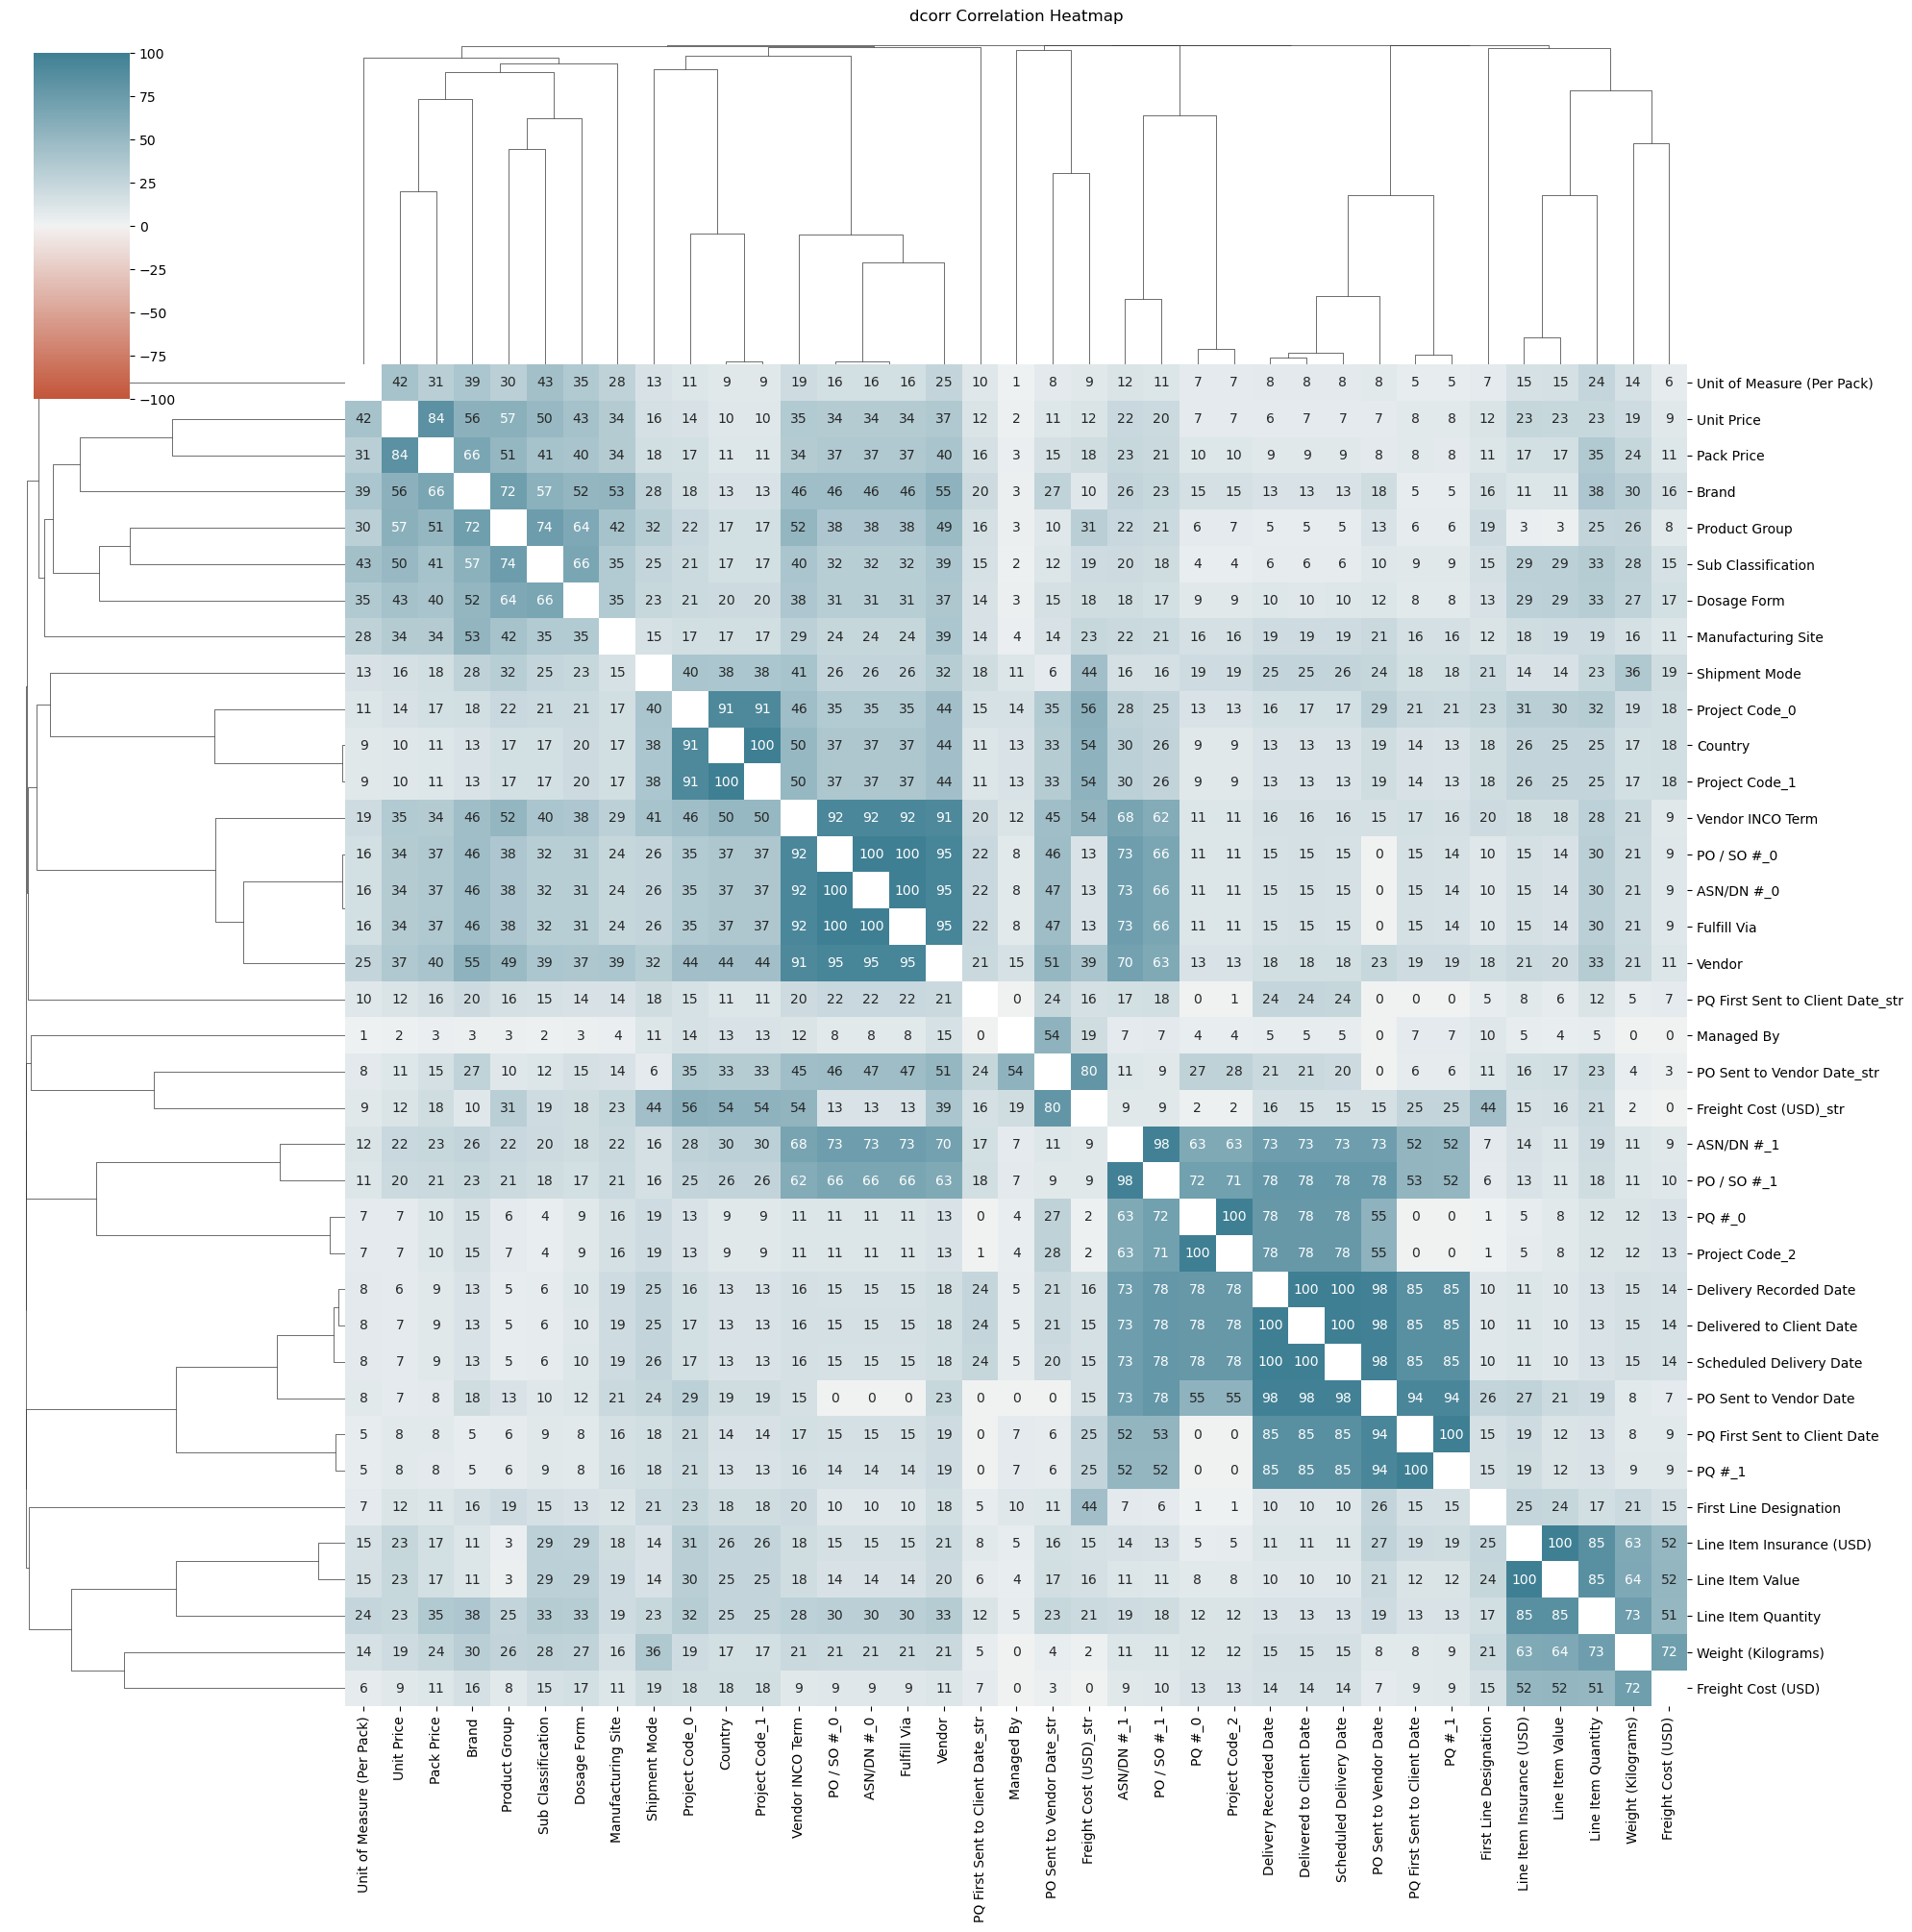

In [9]:
dta.corr_heatmap(corr_method='dcorr', figsize=(20, 20), cluster=True);

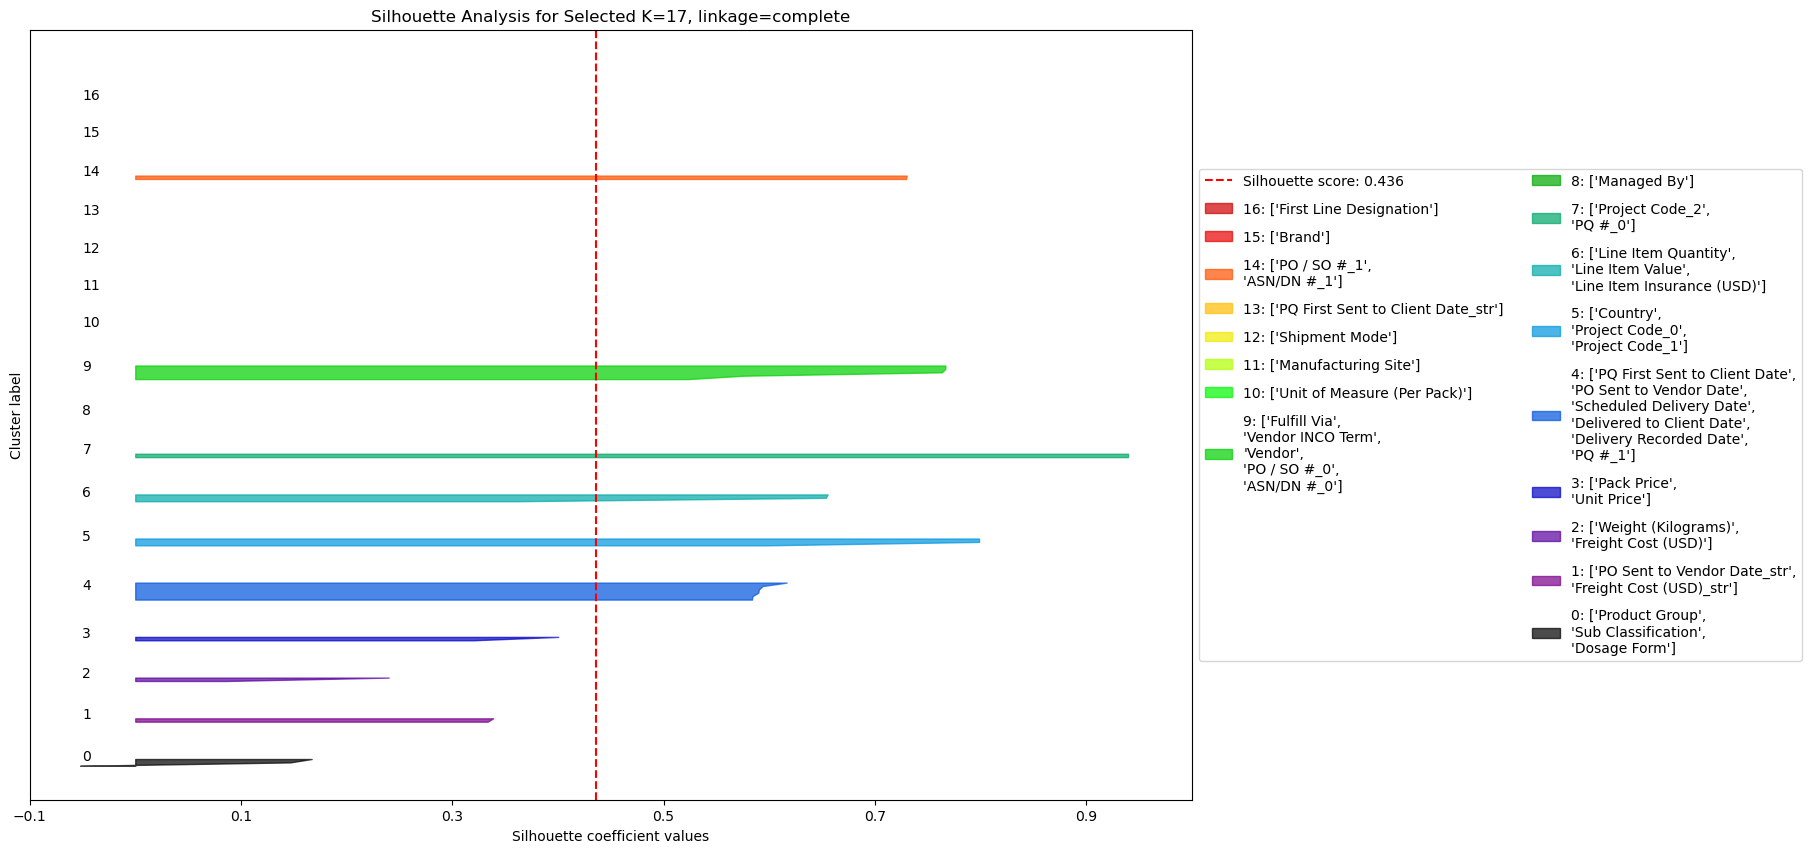

In [19]:
cluster_book = dta.cluster_features(figsize=(15, 10), linkage='complete')

1. ```PQ #_1``` are just dates
2. ```Unit Price = Pack Price / Unit of Measure (Per Pack)```, but rounded to 2 d.p.
3.  ```Pack Price = Line Item Value / Line Item Quantity```
4.  We should normalize ```Line Item Insurance (USD)```  by ```Line Item Value```
5.  We should normalize ```Freight```  by ```Weight```
6.  ```Project Code_1``` is ```Country```

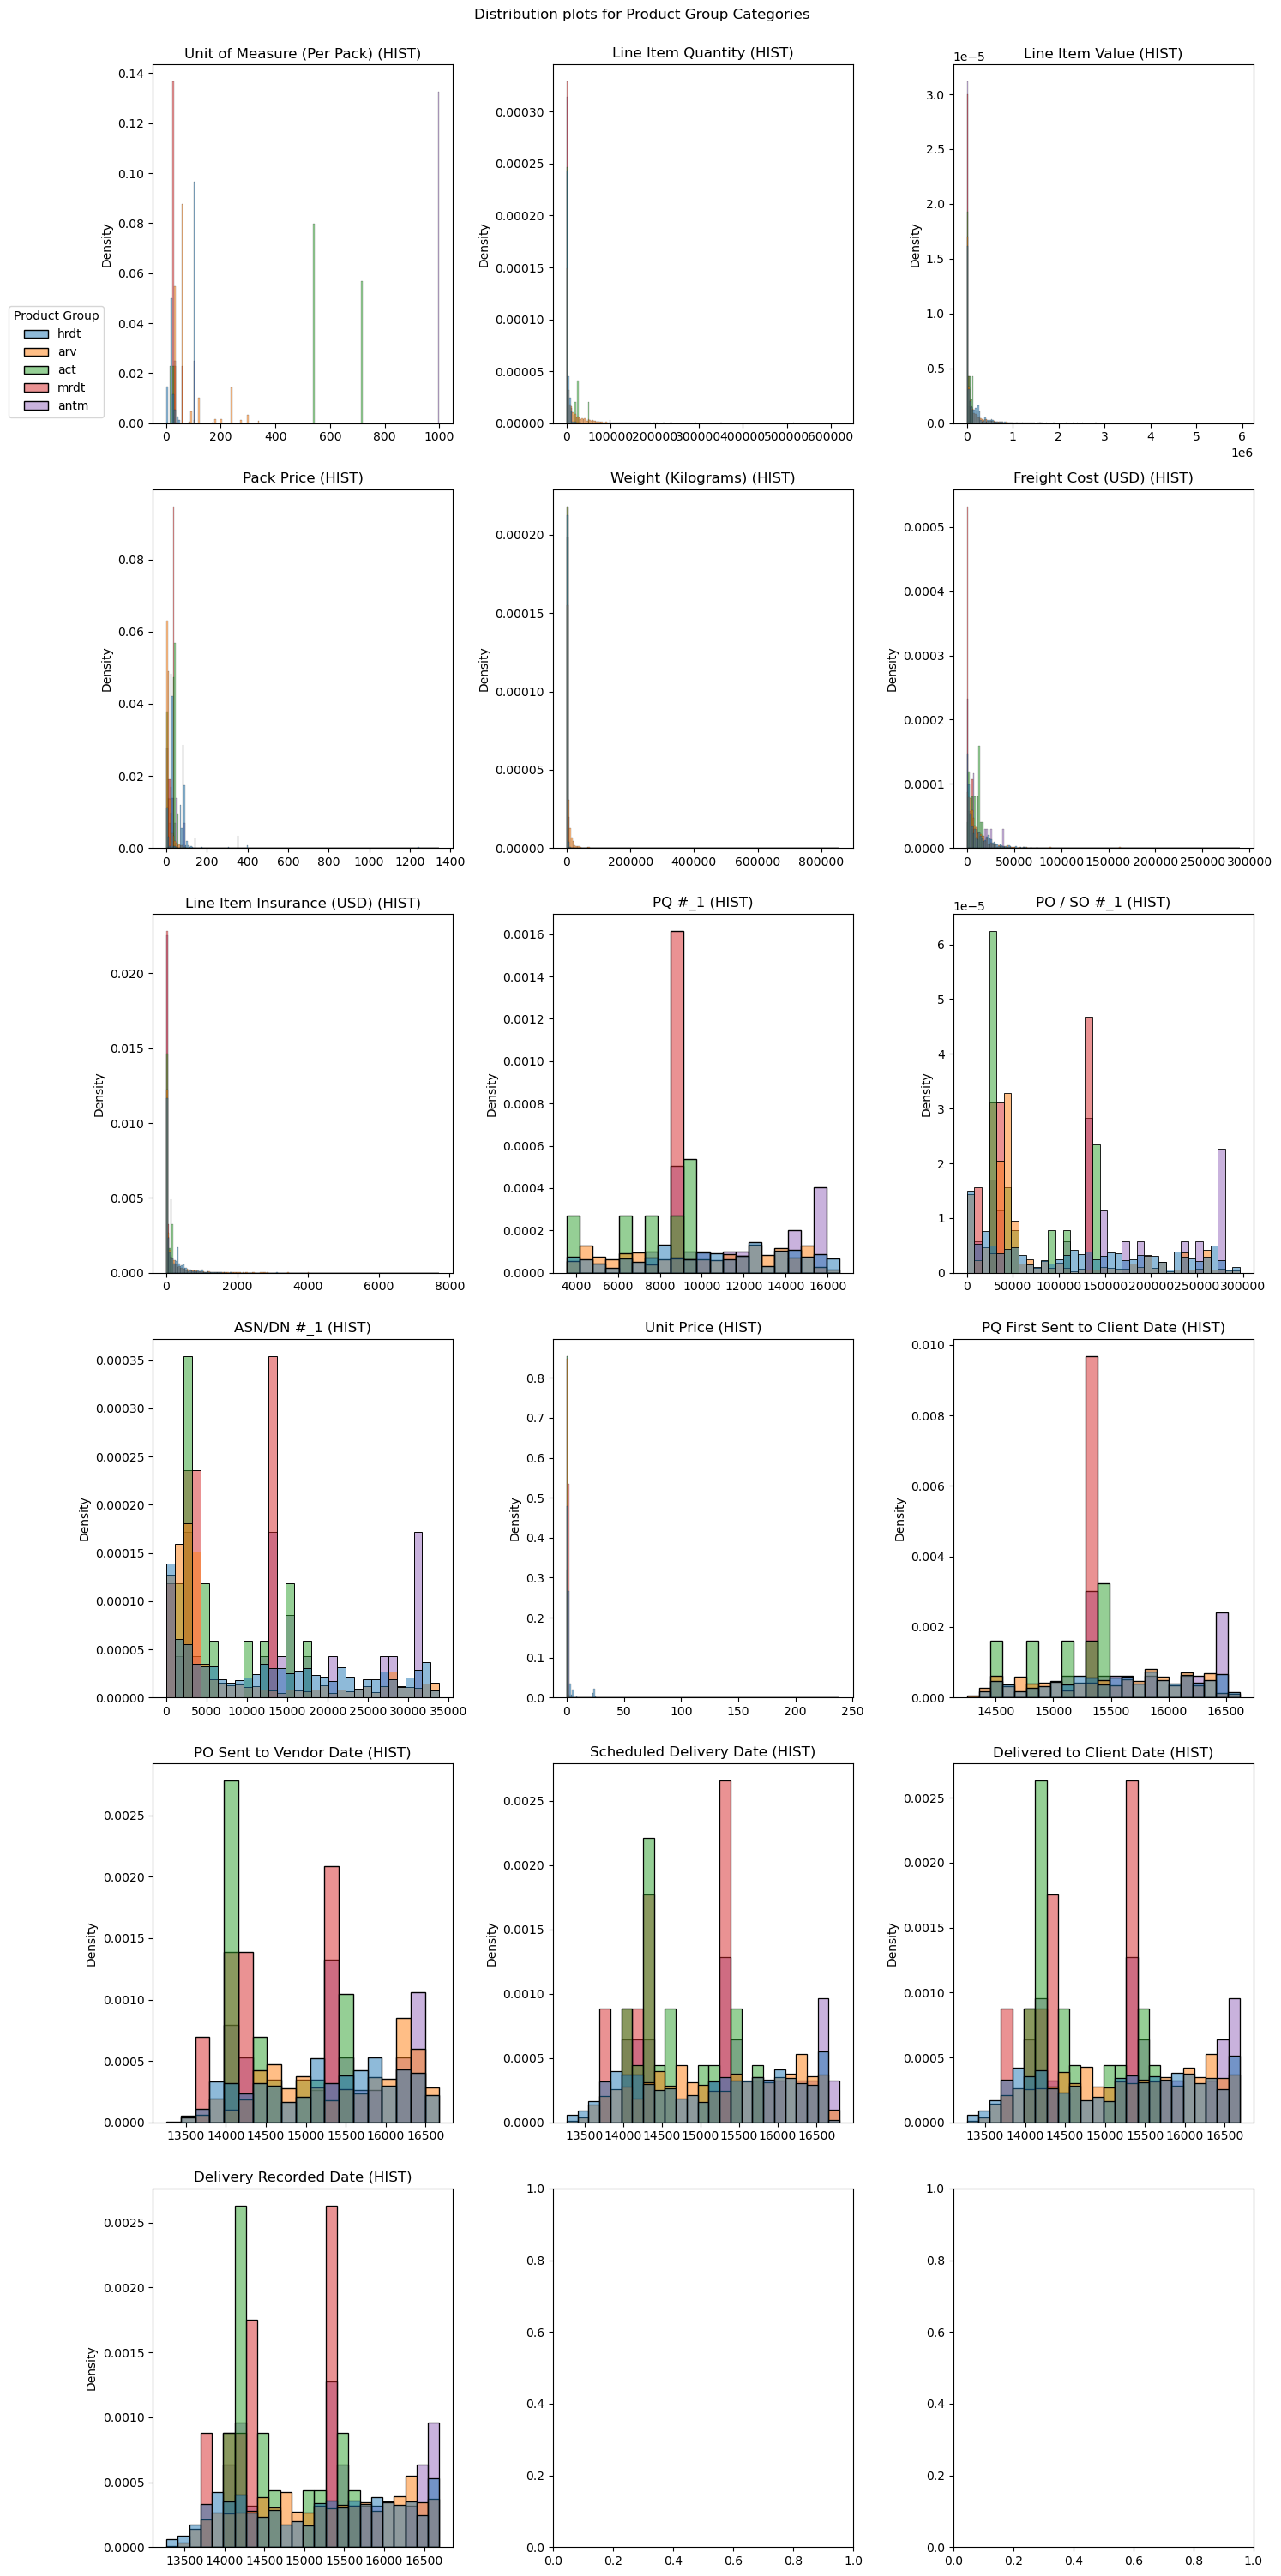

In [11]:
dta.dist_plot_by_categ('Product Group', kind='hist')

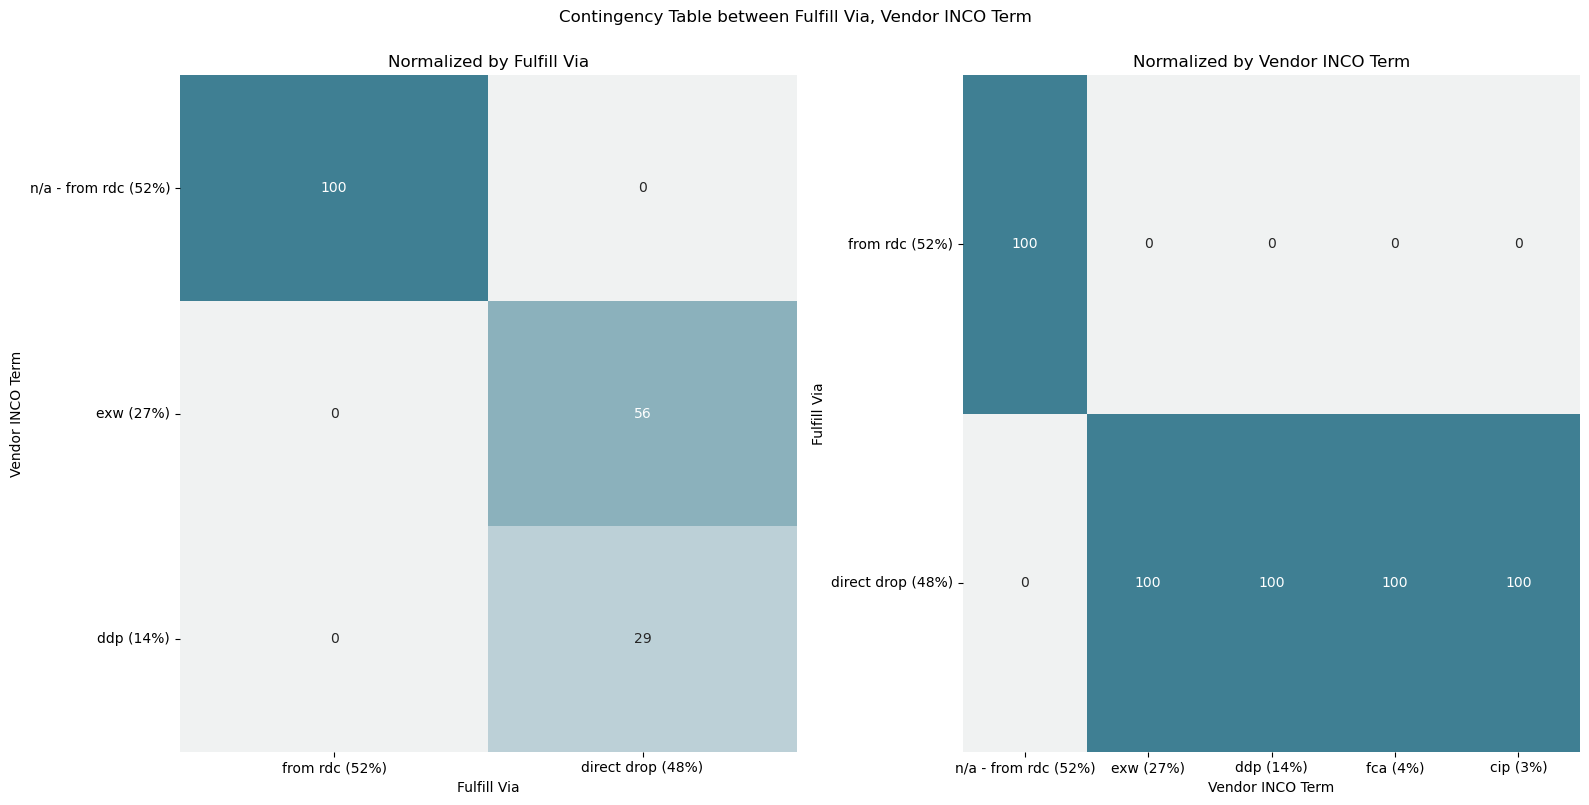

In [12]:
dta.plot_contingency('Fulfill Via', 'Vendor INCO Term', corr=False);

### 2.1 Feature Engineering

In [13]:
df2 = dta.df.copy()

df2['Insurance Ratio'] = df2['Line Item Insurance (USD)'] / df2['Line Item Value']
# df2['Freight/kg'] = df2['Freight Cost (USD)'] / df2['Weight (Kilograms)']
# df2['Unit Weight'] = df2['Weight (Kilograms)'] / df2['Line Item Quantity'] / df2['Unit of Measure (Per Pack)']
df2

,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,PQ First Sent to Client Date,PO Sent to Vendor Date,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,...,quinine,raltegravir,ritonavir,saquinavir,stavudine,sulfadoxine,tenofovir,zidovudine,Unit Price,Insurance Ratio
ID,,,,,,,,,,,,,,,,,,,,,
1,9,2,0,5,0,NaN,NaN,13301.0,13301.0,13301.0,...,3,2,7,3,8,2,3,6,0.97,NaN
3,40,2,0,5,0,NaN,NaN,13466.0,13466.0,13466.0,...,0,0,0,0,0,0,0,0,0.03,NaN
4,9,2,0,6,0,NaN,NaN,13387.0,13387.0,13387.0,...,3,2,7,3,8,2,3,6,0.80,NaN
15,40,2,0,5,0,NaN,NaN,13392.0,13392.0,13392.0,...,0,0,0,0,0,0,0,0,0.07,NaN
16,40,2,0,5,0,NaN,NaN,13371.0,13371.0,13371.0,...,0,0,0,0,6,0,0,0,0.05,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86818,42,2,1,7,4,16359.0,NaN,16647.0,16631.0,16636.0,...,0,0,0,0,0,0,0,2,0.06,0.001177
86819,9,2,1,7,4,16367.0,NaN,16647.0,16653.0,16654.0,...,0,0,0,0,0,0,0,5,0.11,0.001177
86821,41,2,1,7,4,16294.0,NaN,16678.0,16672.0,16681.0,...,0,0,0,0,0,0,2,0,0.33,0.001028


,PQ First Sent to Client Date,PO Sent to Vendor Date,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,pct
0,0.20,0.40,0.800000,0.800000,0.800000,0.236633
1,0.25,-1.00,1.000000,0.625000,0.625000,0.169605
2,-1.00,-1.00,0.666667,0.666667,0.666667,0.167280
3,0.20,0.40,0.700000,0.700000,1.000000,0.070806
4,-1.00,0.25,0.750000,0.750000,0.750000,0.055405


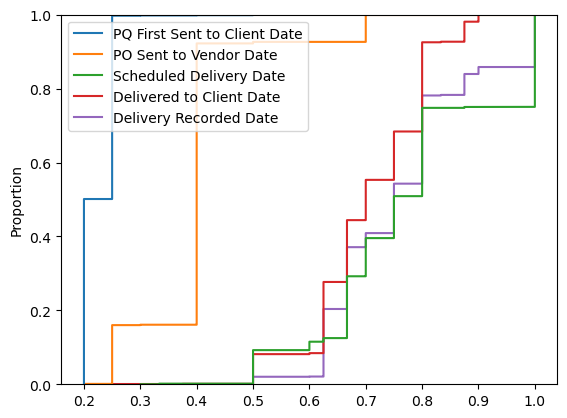

In [14]:
date_rank = dta.df[dta.date_cols].rank(axis=1, pct=True)

def cate_joint_cnt(df_cate):
    df_cate_cnt = df_cate.groupby(df_cate.columns.to_list()).size().sort_values(ascending=False)
    df_cate_cnt = df_cate_cnt.rename('pct')
    df_cate_cnt = df_cate_cnt / df_cate_cnt.sum()
    df_cate_cnt = df_cate_cnt.reset_index()
    return df_cate_cnt
    
display(cate_joint_cnt(date_rank.fillna(-1)).head(5))
sns.ecdfplot(date_rank);

In [15]:
df2['POCycle'] = df2['PO Sent to Vendor Date'] - df2['PQ First Sent to Client Date']
df2['Delay'] = df2['Delivered to Client Date'] - df2['Scheduled Delivery Date']
df2['IsDelay'] = (df2['Delay'] > 0).astype(int)
# df2['Recorded Minus Scheduled'] = df2['Delivery Recorded Date'] - df2['Scheduled Delivery Date']
df2

,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,PQ First Sent to Client Date,PO Sent to Vendor Date,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,...,saquinavir,stavudine,sulfadoxine,tenofovir,zidovudine,Unit Price,Insurance Ratio,POCycle,Delay,IsDelay
ID,,,,,,,,,,,,,,,,,,,,,
1,9,2,0,5,0,NaN,NaN,13301.0,13301.0,13301.0,...,3,8,2,3,6,0.97,NaN,NaN,0.0,0
3,40,2,0,5,0,NaN,NaN,13466.0,13466.0,13466.0,...,0,0,0,0,0,0.03,NaN,NaN,0.0,0
4,9,2,0,6,0,NaN,NaN,13387.0,13387.0,13387.0,...,3,8,2,3,6,0.80,NaN,NaN,0.0,0
15,40,2,0,5,0,NaN,NaN,13392.0,13392.0,13392.0,...,0,0,0,0,0,0.07,NaN,NaN,0.0,0
16,40,2,0,5,0,NaN,NaN,13371.0,13371.0,13371.0,...,0,6,0,0,0,0.05,NaN,NaN,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86818,42,2,1,7,4,16359.0,NaN,16647.0,16631.0,16636.0,...,0,0,0,0,2,0.06,0.001177,NaN,-16.0,0
86819,9,2,1,7,4,16367.0,NaN,16647.0,16653.0,16654.0,...,0,0,0,0,5,0.11,0.001177,NaN,6.0,1
86821,41,2,1,7,4,16294.0,NaN,16678.0,16672.0,16681.0,...,0,0,0,2,0,0.33,0.001028,NaN,-6.0,0


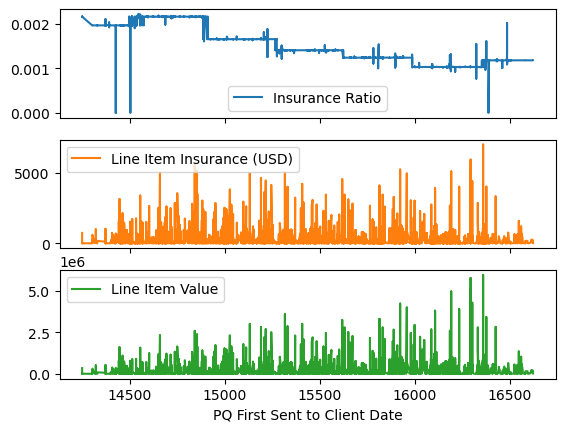

In [16]:
insur_trend = df2[['PQ First Sent to Client Date', 'Insurance Ratio', 'Line Item Insurance (USD)', 'Line Item Value']]
insur_trend = insur_trend.set_index('PQ First Sent to Client Date').sort_index()
insur_trend.plot(subplots=True);

100%|███████████████████████████████████████| 465/465 [00:00<00:00, 2047.04it/s]


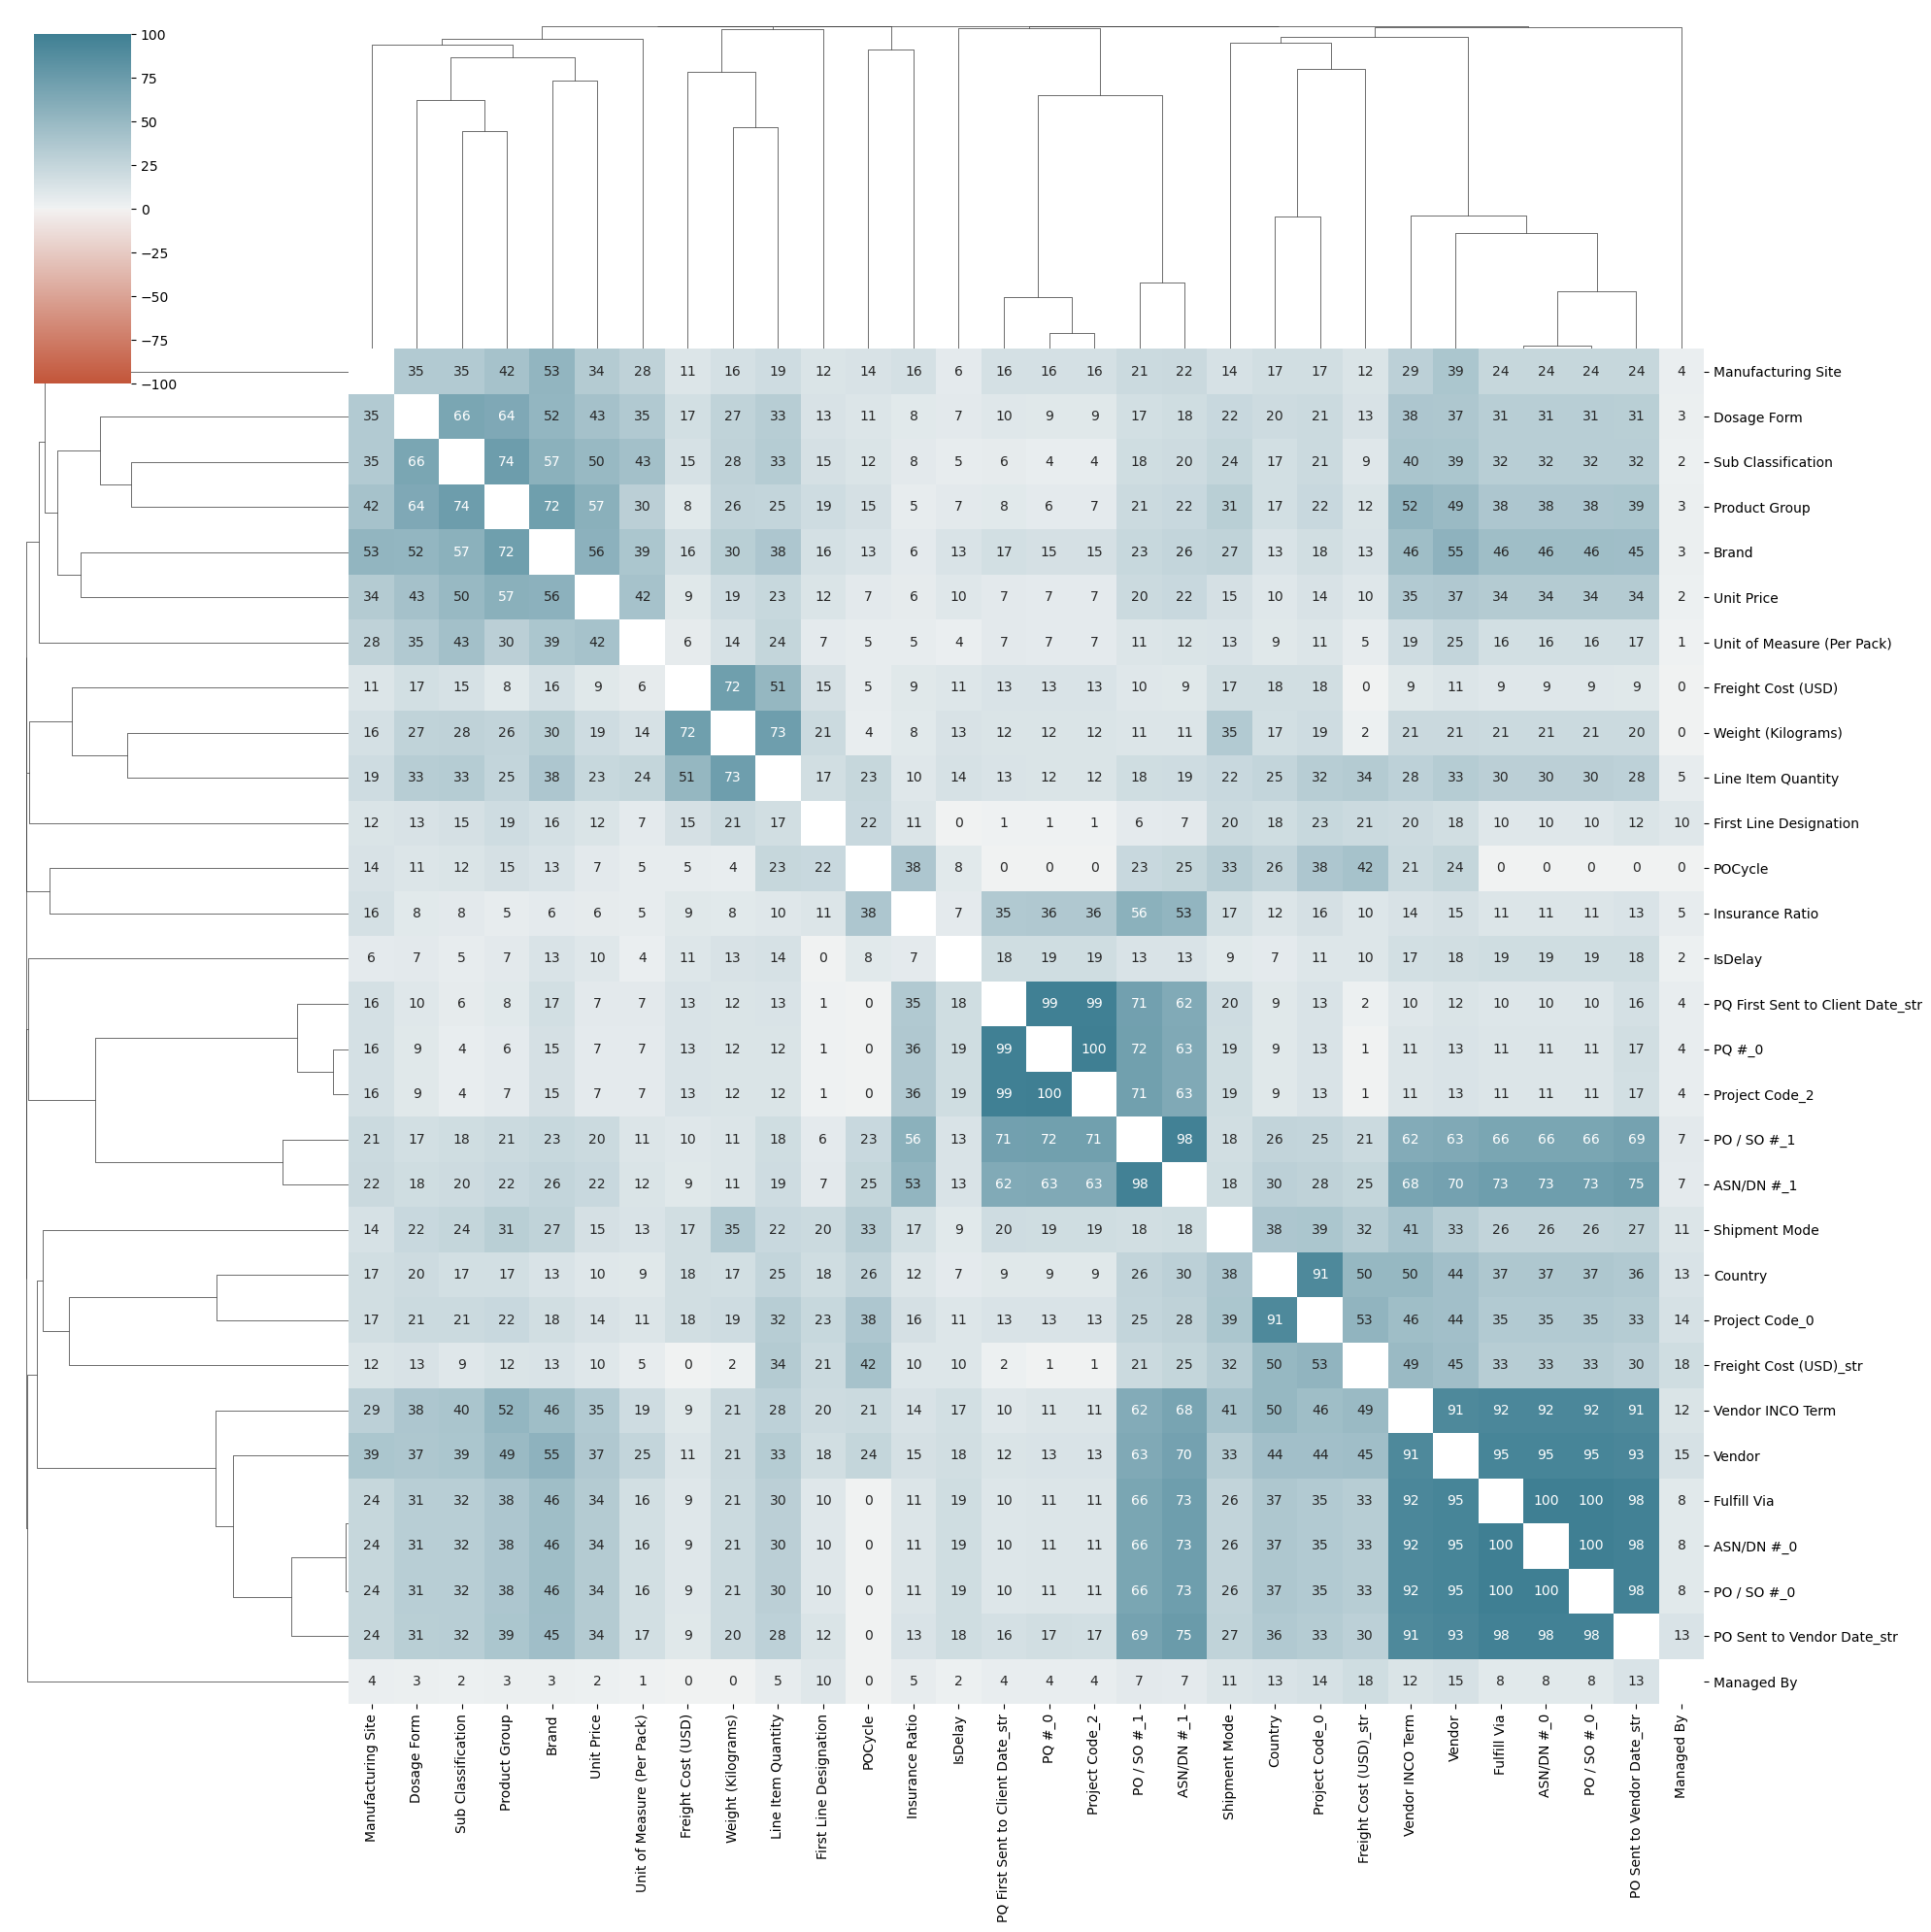

In [17]:
df3 = df2.drop(columns=['Line Item Insurance (USD)',
                        #'Freight Cost (USD)',
                        # 'Weight (Kilograms)',
                        
                       'PQ #_1',
                        *dta.date_cols,
                        
                       'Pack Price',
                       'Line Item Value',
                       'Project Code_1',

                        'Delay'] 
)

df3 = df3[np.isfinite(df3)]

corr2 = pstats.distance_correlation(df3.drop(columns=dta.sparse_cols), disc_features=dta.disc_cols, rank=True)
pplot.plot_corr(corr2, figsize=(20, 20), cluster=True)

In [18]:
cont_cols = [c for c in df.columns if (c not in [*dta.disc_cols, *dta.sparse_cols, 'IsDelay'])]

df = df3.copy()
# df.to_csv('../Processed/SCMS.csv')
print(cont_cols)

df

['Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'PQ First Sent to Client Date', 'PO Sent to Vendor Date', 'Scheduled Delivery Date', 'Delivered to Client Date', 'Delivery Recorded Date', 'Item Description', 'Molecule/Test Type', 'Dosage', 'Unit of Measure (Per Pack)', 'Line Item Quantity', 'Line Item Value', 'Pack Price', 'Unit Price', 'Weight (Kilograms)', 'Freight Cost (USD)', 'Line Item Insurance (USD)']


,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,Product Group,Sub Classification,Vendor,Brand,Dosage Form,...,ritonavir,saquinavir,stavudine,sulfadoxine,tenofovir,zidovudine,Unit Price,Insurance Ratio,POCycle,IsDelay
ID,,,,,,,,,,,,,,,,,,,,,
1,9,2,0,5,0,3,2,56,33,15,...,7,3,8,2,3,6,0.97,NaN,NaN,0
3,40,2,0,5,0,2,5,13,15,8,...,0,0,0,0,0,0,0.03,NaN,NaN,0
4,9,2,0,6,0,3,2,0,11,15,...,7,3,8,2,3,6,0.80,NaN,NaN,0
15,40,2,0,5,0,2,1,65,15,10,...,0,0,0,0,0,0,0.07,NaN,NaN,0
16,40,2,0,5,0,2,1,13,15,0,...,0,0,6,0,0,0,0.05,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86818,42,2,1,7,4,2,5,59,15,2,...,0,0,0,0,0,2,0.06,0.001177,NaN,0
86819,9,2,1,7,4,2,1,59,15,12,...,0,0,0,0,0,5,0.11,0.001177,NaN,1
86821,41,2,1,7,4,2,1,59,15,12,...,0,0,0,0,2,0,0.33,0.001028,NaN,0
